
# Citi Bike - Next Steps Journey Based on v7

This notebook is the continuation notebook for the **v7 capacity-fix workflow**.

It does three things:

1. Pull the key stored results out of the v7 modeling notebook so you can explain the current state quickly.
2. Load the v7 `feature_df_model_ready` table and verify that the availability-style target is healthy.
3. Run follow-on experiments that now make sense **after** the capacity fix: top-N sensitivity, feature ablation, capacity-reliability comparison, and operational alert tasks.

---

## The current state in one sentence

The project is no longer blocked on capacity matching. In v7, the main question shifts from **"Can we fix availability?"** to **"Which follow-on experiments best strengthen the availability story?"**


In [1]:

try:
    from google.colab import drive
    drive.mount('/content/drive')

except ModuleNotFoundError:
    print('google.colab is not available in this environment - skipping Drive mount.')


Mounted at /content/drive


In [2]:

from pathlib import Path
import io
import json
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)


def locate_existing_path(candidates):
    for path in candidates:
        path = Path(path)
        if path.exists():
            return path
    return None


SOURCE_NOTEBOOK_CANDIDATES = [
    Path('/content/CitiBike_2025_EDA_Modeling_v7_capacity_fix.ipynb'),
    Path('/content/CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb'),
    Path('CitiBike_2025_EDA_Modeling_v7_capacity_fix.ipynb'),
    Path('CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb'),
    Path('/mnt/data/CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb'),
    Path('/mnt/data/CitiBike_2025_EDA_Modeling_v7_capacity_fix.ipynb'),
]

FEATURE_CACHE_CANDIDATES = [
    Path('outputs/feature_df_model_ready_2025_v7_final.parquet'),
    Path('outputs/feature_df_model_ready_2025_v7.parquet'),
    Path('/content/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/content/feature_df_model_ready_2025_v7.parquet'),
    Path('/content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/content/drive/MyDrive/feature_df_model_ready_2025_v7.parquet'),
    Path('/mnt/data/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/mnt/data/feature_df_model_ready_2025_v7.parquet'),
    Path('/mnt/data/outputs/feature_df_model_ready_2025_v7_final.parquet'),
    Path('/mnt/data/outputs/feature_df_model_ready_2025_v7.parquet'),
]

RUN_HEAVY_EXPERIMENTS = True
PRIMARY_TARGET = 'utilization_ratio_next_hour'
DEFAULT_TOP_N_STATIONS = 150
TOP_N_GRID = [50, 150, 300]
MAX_ROWS_PER_EXPERIMENT = 350_000
RANDOM_STATE = 42



## Optional: copy the v7 parquet from Drive into the runtime

Run this cell only if your runtime cannot see the v7 parquet directly but the file exists in Drive.


In [4]:

# Uncomment and adjust if needed.
# import shutil
# src = '/content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet'
# dst = '/content/feature_df_model_ready_2025_v7_final.parquet'
# shutil.copy2(src, dst)
# print('Copied to:', dst)


## 1) Quick file checks

In [3]:
print('Source notebook candidates:')
for p in SOURCE_NOTEBOOK_CANDIDATES:
    print(' ', p, '->', p.exists())

print('\nFeature cache candidates:')
for p in FEATURE_CACHE_CANDIDATES:
    print(' ', p, '->', p.exists())

resolved_feature = locate_existing_path(FEATURE_CACHE_CANDIDATES)
resolved_source = locate_existing_path(SOURCE_NOTEBOOK_CANDIDATES)

print('\nResolved source notebook:', resolved_source)
print('Resolved feature cache:', resolved_feature)

if resolved_feature is not None:
    try:
        size = resolved_feature.stat().st_size
        with open(resolved_feature, 'rb') as f:
            head = f.read(4)
            f.seek(-4, 2)
            tail = f.read(4)
        print(f'Parquet integrity check -> size={size:,} head={head} tail={tail}')
    except Exception as e:
        print('Parquet integrity check failed:', e)


Source notebook candidates:
  /content/CitiBike_2025_EDA_Modeling_v7_capacity_fix.ipynb -> False
  /content/CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb -> True
  CitiBike_2025_EDA_Modeling_v7_capacity_fix.ipynb -> False
  CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb -> True
  /mnt/data/CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb -> False
  /mnt/data/CitiBike_2025_EDA_Modeling_v7_capacity_fix.ipynb -> False

Feature cache candidates:
  outputs/feature_df_model_ready_2025_v7_final.parquet -> False
  outputs/feature_df_model_ready_2025_v7.parquet -> False
  /content/feature_df_model_ready_2025_v7_final.parquet -> False
  /content/feature_df_model_ready_2025_v7.parquet -> False
  /content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet -> True
  /content/drive/MyDrive/feature_df_model_ready_2025_v7.parquet -> False
  /mnt/data/feature_df_model_ready_2025_v7_final.parquet -> False
  /mnt/data/feature_df_model_ready_2025_v7.parquet -> False
  /mnt/data/ou


## 2) Pull the key stored results out of the v7 notebook

The v7 notebook already contains stored outputs. This section reads those outputs directly so you can recover the main results even before rerunning heavy experiments.


In [4]:
def load_notebook(path: Path):
    if not path.exists():
        raise FileNotFoundError(f'Notebook not found: {path}')
    return json.loads(path.read_text(encoding='utf-8'))


def cell_source(cell):
    return ''.join(cell.get('source', []))


def first_stream_text(cell):
    texts = []
    for out in cell.get('outputs', []):
        if out.get('output_type') == 'stream':
            texts.append(''.join(out.get('text', [])))
    return '\n'.join(texts)


def html_tables_from_cell(cell):
    tables = []
    for out in cell.get('outputs', []):
        if out.get('output_type') in {'display_data', 'execute_result'}:
            data = out.get('data', {})
            html = data.get('text/html')
            if html:
                html_str = ''.join(html) if isinstance(html, list) else html
                try:
                    parsed = pd.read_html(io.StringIO(html_str))
                    tables.extend(parsed)
                except Exception:
                    pass
    return tables


def find_cell(nb, needle: str):
    for cell in nb['cells']:
        if needle in cell_source(cell):
            return cell
    raise KeyError(f'Could not find cell containing: {needle}')


SOURCE_NOTEBOOK = locate_existing_path(SOURCE_NOTEBOOK_CANDIDATES)
if SOURCE_NOTEBOOK is None:
    raise FileNotFoundError('Could not find the v7 source notebook.')

nb_json = load_notebook(SOURCE_NOTEBOOK)

config_cell = find_cell(nb_json, 'TOP_N_STATIONS_FOR_MODEL =')
agg_cell = find_cell(nb_json, 'station_hour_cache = OUTPUT_DIR')
coverage_cell = find_cell(nb_json, 'Rows with utilization proxy:')
summary_cell = find_cell(nb_json, 'target_summary = pd.DataFrame(summary_rows)')
primary_cell = find_cell(nb_json, 'print("Primary target:", PRIMARY_TARGET)')
weather_error_cell = find_cell(nb_json, 'weather_summary = weather_error.groupby("is_precipitating"')
importance_cell = find_cell(nb_json, 'importance_df = extract_feature_importance(primary_result["best_model"])')

config_text = cell_source(config_cell)
agg_text = first_stream_text(agg_cell)
coverage_text = first_stream_text(coverage_cell)
summary_tables = html_tables_from_cell(summary_cell)
primary_tables = html_tables_from_cell(primary_cell)
weather_tables = html_tables_from_cell(weather_error_cell)
importance_tables = html_tables_from_cell(importance_cell)

stored = {
    'top_n_stations': int(re.search(r'TOP_N_STATIONS_FOR_MODEL\s*=\s*(\d+)', config_text).group(1)),
    'agg_unique_stations': int(re.search(r'Unique stations:\s*(\d+)', agg_text).group(1)),
    'agg_rows': int(re.search(r'\((\d+),\s*6\)', agg_text).group(1)),
    'utilization_coverage': float(re.search(r'Rows with utilization proxy:\s*([0-9.]+)', coverage_text).group(1)),
    'target_summary': summary_tables[0] if summary_tables else None,
    'primary_validation': primary_tables[0] if len(primary_tables) >= 1 else None,
    'primary_test': primary_tables[1] if len(primary_tables) >= 2 else None,
    'weather_error': weather_tables[0] if weather_tables else None,
    'feature_importance': importance_tables[0] if importance_tables else None,
}

print('Read stored outputs from:', SOURCE_NOTEBOOK)
print('Configured top-N stations in v7:', stored['top_n_stations'])
print('Aggregated station-hour rows:', f"{stored['agg_rows']:,}")
print('Unique stations:', stored['agg_unique_stations'])
print('Utilization proxy row coverage:', f"{stored['utilization_coverage']:.2%}")


Read stored outputs from: /content/CitiBike_2025_EDA_Modeling_v7_capacity_fix (2).ipynb
Configured top-N stations in v7: 150
Aggregated station-hour rows: 11,966,828
Unique stations: 2428
Utilization proxy row coverage: 99.90%


In [5]:

if stored['target_summary'] is not None:
    display(Markdown('### Stored v7 target summary'))
    display(stored['target_summary'])

if stored['primary_validation'] is not None:
    display(Markdown('### Stored validation results for the primary target'))
    display(stored['primary_validation'])

if stored['primary_test'] is not None:
    display(Markdown('### Stored test results for the primary target'))
    display(stored['primary_test'])

if stored['feature_importance'] is not None:
    display(Markdown('### Stored feature importance for the primary target'))
    display(stored['feature_importance'].head(15))


### Stored v7 target summary

,Unnamed: 0,target,best_validation_model,validation_rmse,validation_mae,validation_r2,final_test_rmse,final_test_mae,final_test_r2
0,0,utilization_ratio_next_hour,Random Forest (deeper),0.112013,0.074766,0.850207,0.096278,0.066015,0.846928
1,1,departures_next_hour,Random Forest (deeper),5.887496,4.038321,0.784847,4.628021,3.288031,0.647971
2,2,arrivals_next_hour,Random Forest (deeper),6.117496,4.106759,0.775879,4.865003,3.343166,0.631802
3,3,net_flow_next_hour,Random Forest (deeper),5.810532,3.979764,0.501117,4.472939,3.083920,0.397272


### Stored validation results for the primary target

,Unnamed: 0,rmse,mae,r2,target,model,split
0,0,0.112013,0.074766,0.850207,utilization_ratio_next_hour,Random Forest (deeper),validation
1,1,0.117935,0.078558,0.833948,utilization_ratio_next_hour,Random Forest,validation
2,2,0.163268,0.110615,0.681756,utilization_ratio_next_hour,Linear Regression,validation
3,3,0.175648,0.114197,0.631666,utilization_ratio_next_hour,Naive baseline,validation


### Stored test results for the primary target

,Unnamed: 0,rmse,mae,r2,target,model,split
0,0,0.096278,0.066015,0.846928,utilization_ratio_next_hour,Random Forest (deeper),test
1,1,0.101104,0.069033,0.831198,utilization_ratio_next_hour,Random Forest,test
2,2,0.123659,0.088451,0.747481,utilization_ratio_next_hour,Linear Regression,test
3,3,0.144952,0.093857,0.653027,utilization_ratio_next_hour,Naive baseline,test


### Stored feature importance for the primary target

,Unnamed: 0,feature,importance
0,0,utilization_ratio_lag_1,0.507488
1,1,is_nearly_full,0.183060
2,2,is_nearly_empty,0.129419
3,3,hour_cos,0.022508
4,4,hour_of_day,0.022348
5,5,utilization_ratio_roll_24,0.015704
6,6,hour_sin,0.014837
7,7,net_flow_roll_3,0.010131
8,8,net_flow_roll_24,0.007186
9,9,lat,0.005487



## 3) What v7 already proves

These are the strongest claims you can already make before running anything else:

- The notebook now supports an **availability-style target**: `utilization_ratio_next_hour`.
- The best model in the stored v7 run is **Random Forest (deeper)**.
- The availability target performs much better than raw `net_flow_next_hour` and is competitive with the easier departures/arrivals targets.
- The strongest predictive signals are mostly **station state features** such as lagged utilization and nearly-empty / nearly-full flags.
- Weather still matters for context, but it is clearly not the main source of predictive power.
- Because capacity is now available on almost all rows, the project story can move from **repairing the target** to **stress-testing the target**.


## 4) Load the v7 feature dataframe

In [6]:

FEATURE_CACHE = locate_existing_path(FEATURE_CACHE_CANDIDATES)
if FEATURE_CACHE is None:
    raise FileNotFoundError('Could not find a v7 feature parquet. Update FEATURE_CACHE_CANDIDATES if needed.')

print('Loading feature_df from:', FEATURE_CACHE)
feature_df = pd.read_parquet(FEATURE_CACHE)

if 'station_key' in feature_df.columns:
    feature_df['station_key'] = feature_df['station_key'].astype('category')
if 'station_cluster' in feature_df.columns:
    feature_df['station_cluster'] = feature_df['station_cluster'].astype('category')
if 'hour' in feature_df.columns:
    feature_df['hour'] = pd.to_datetime(feature_df['hour'])

print('Loaded shape:', feature_df.shape)
display(feature_df.head())


Loading feature_df from: /content/drive/MyDrive/feature_df_model_ready_2025_v7_final.parquet
Loaded shape: (11966828, 97)


,station_key,hour,departures,arrivals,net_flow,total_activity,station_id,station_name,lat,lng,station_name_norm,gbfs_name,capacity_raw,capacity_known,capacity_imputed,is_active_station,capacity,location_id,temperature_f,precipitation_in,rain_in,snowfall_in,snow_depth_ft,wind_speed_mph,soil_temperature_0_to_7cm (°F),soil_temperature_7_to_28cm (°F),relative_humidity_pct,dew_point_f,apparent_temperature_f,wind_gusts_mph,wind_direction_deg,hour_of_day,day_of_week,month,is_weekend,is_rush_hour,is_commute_peak,is_overnight,hour_sin,hour_cos,dow_sin,dow_cos,is_holiday,is_precipitating,heavy_precip_flag,is_raining,is_snowing,departures_lag_1,departures_lag_2,departures_lag_24,departures_roll_3,departures_roll_24,arrivals_lag_1,arrivals_lag_2,arrivals_lag_24,arrivals_roll_3,arrivals_roll_24,net_flow_lag_1,net_flow_lag_2,net_flow_lag_24,net_flow_roll_3,net_flow_roll_24,total_activity_lag_1,total_activity_lag_2,total_activity_lag_24,total_activity_roll_3,total_activity_roll_24,departures_next_hour,arrivals_next_hour,net_flow_next_hour,estimated_bikes,available_docks,utilization_ratio,is_nearly_empty,is_nearly_full,estimated_bikes_lag_1,estimated_bikes_lag_2,estimated_bikes_lag_24,estimated_bikes_roll_3,estimated_bikes_roll_24,available_docks_lag_1,available_docks_lag_2,available_docks_lag_24,available_docks_roll_3,available_docks_roll_24,utilization_ratio_lag_1,utilization_ratio_lag_2,utilization_ratio_lag_24,utilization_ratio_roll_3,utilization_ratio_roll_24,estimated_bikes_next_hour,available_docks_next_hour,utilization_ratio_next_hour,station_cluster,weather_pc_1,weather_pc_2,weather_pc_3
0,1234.56,2025-06-18 22:00:00,0,1,1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,1.0,70.2,0.004,0.004,0.0,0.0,0.8,72.5,69.8,100.0,70.1,77.8,5.8,214.0,22,2,6,0,0,0,0,-5.000000e-01,0.866025,0.974928,-0.222521,0,1,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,13.0,11.0,0.541667,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,11.0,0.541667,2,2.757381,-0.368786,-1.766357
1,1234.56,2025-06-18 23:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,71.4,0.004,0.004,0.0,0.0,2.7,72.5,69.4,98.0,71.0,78.8,7.6,195.0,23,2,6,0,0,0,0,-2.588190e-01,0.965926,0.974928,-0.222521,0,1,0,1,0,0.0,NaN,NaN,0.000000,0.000000,1.0,NaN,NaN,1.000000,1.000000,1.0,NaN,NaN,1.000000,1.0,1.0,NaN,NaN,1.000000,1.000000,1.0,0.0,-1.0,13.0,11.0,0.541667,0,0,13.0,NaN,NaN,13.000000,13.000000,11.0,NaN,NaN,11.000000,11.000000,0.541667,NaN,NaN,0.541667,0.541667,11.0,13.0,0.458333,2,2.690833,-0.238696,-1.318855
2,1234.56,2025-06-19 23:00:00,1,0,-1,1,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,0.0,73.0,0.000,0.000,0.0,0.0,10.6,74.5,73.6,83.0,67.5,75.2,23.3,234.0,23,3,6,0,0,0,0,-2.588190e-01,0.965926,0.433884,-0.900969,1,0,0,0,0,1.0,0.0,NaN,0.500000,0.500000,1.0,1.0,NaN,1.000000,1.000000,0.0,1.0,NaN,0.500000,0.5,2.0,1.0,NaN,1.500000,1.500000,1.0,1.0,0.0,11.0,13.0,0.458333,0,0,13.0,13.0,NaN,13.000000,13.000000,11.0,11.0,NaN,11.000000,11.000000,0.541667,0.541667,NaN,0.541667,0.541667,12.0,12.0,0.500000,2,1.421356,0.119499,1.292002
3,1234.56,2025-06-20 09:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,3.0,72.6,0.000,0.000,0.0,0.0,11.3,71.7,71.2,55.0,55.5,69.6,26.8,284.0,9,4,6,0,1,1,0,7.071068e-01,-0.707107,-0.433884,-0.900969,0,0,0,0,0,1.0,1.0,NaN,0.666667,0.666667,0.0,1.0,NaN,0.666667,0.666667,-1.0,0.0,NaN,0.000000,0.0,1.0,2.0,NaN,1.333333,1.333333,1.0,1.0,0.0,12.0,12.0,0.500000,0,0,11.0,13.0,NaN,12.333333,12.333333,13.0,11.0,NaN,11.666667,11.666667,0.458333,0.541667,NaN,0.513889,0.513889,12.0,12.0,0.500000,2,0.488080,-0.150773,2.193309
4,1234.56,2025-06-20 12:00:00,1,1,0,2,1234.56,Morgan HCT Charging,40.708948,-73.932777,morgan hct charging,<NA>,NaN,0,1,0,24.0,2.0,79.3,0.000,0.000,0.0,0.0,11.2,78.9,72.3,46.0,56.8,79.9,27.7,286.0,

## 5) Sanity checks for the availability-style target

,column,non_null_rate,dtype
0,station_key,1.000000,category
1,hour,1.000000,datetime64[ns]
2,departures,1.000000,int32
3,arrivals,1.000000,int32
4,net_flow,1.000000,int32
5,total_activity,1.000000,int32
6,station_id,1.000000,string
7,station_name,1.000000,string
8,lat,1.000000,string
9,lng,1.000000,string


,count,mean,std,min,25%,50%,75%,max
capacity,11966828.0,35.013214,19.150441,0.0,21.000000,27.0,43.000000,123.0
capacity_raw,11829473.0,35.141091,19.224282,0.0,21.000000,27.0,43.000000,123.0
capacity_known,11966828.0,0.988522,0.106519,0.0,1.000000,1.0,1.000000,1.0
capacity_imputed,11966828.0,0.011478,0.106519,0.0,0.000000,0.0,0.000000,1.0
estimated_bikes,11955321.0,17.058826,13.602242,0.0,9.000000,13.0,21.500000,123.0
available_docks,11955321.0,17.988117,12.835156,0.0,10.500000,14.5,22.500000,123.0
utilization_ratio,11955321.0,0.476879,0.218159,0.0,0.369565,0.5,0.586957,1.0
utilization_ratio_next_hour,11952895.0,0.476874,0.218179,0.0,0.369565,0.5,0.586957,1.0
is_nearly_empty,11966828.0,0.071982,0.258458,0.0,0.000000,0.0,0.000000,1.0
is_nearly_full,11966828.0,0.048334,0.214471,0.0,0.000000,0.0,0.000000,1.0


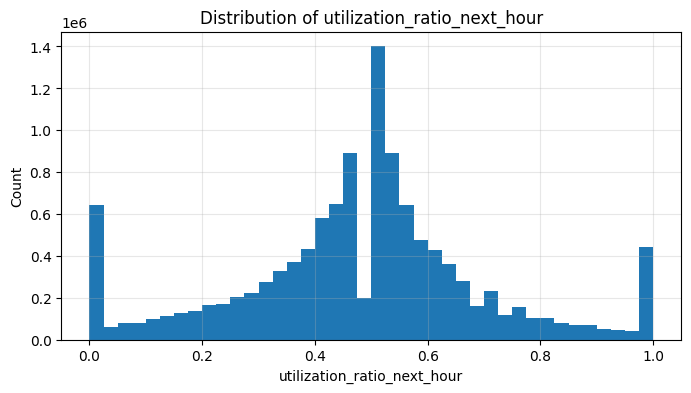

In [7]:

coverage = pd.DataFrame({
    'column': feature_df.columns,
    'non_null_rate': [feature_df[c].notna().mean() for c in feature_df.columns],
    'dtype': [str(feature_df[c].dtype) for c in feature_df.columns],
}).sort_values('non_null_rate', ascending=False)

display(coverage.head(40))

focus_cols = [
    c for c in [
        'capacity', 'capacity_raw', 'capacity_known', 'capacity_imputed',
        'estimated_bikes', 'available_docks', 'utilization_ratio', 'utilization_ratio_next_hour',
        'is_nearly_empty', 'is_nearly_full'
    ] if c in feature_df.columns
]

if focus_cols:
    display(feature_df[focus_cols].describe(include='all').T)

if 'utilization_ratio_next_hour' in feature_df.columns:
    plt.figure(figsize=(8, 4))
    feature_df['utilization_ratio_next_hour'].dropna().clip(0, 1).hist(bins=40)
    plt.title('Distribution of utilization_ratio_next_hour')
    plt.xlabel('utilization_ratio_next_hour')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    plt.show()


## 6) Helpers for follow-on experiments

In [8]:

def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float32)


FEATURE_GROUPS = {
    'calendar': [
        'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_holiday',
        'is_rush_hour', 'is_commute_peak', 'is_overnight', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
    ],
    'weather': [
        'is_precipitating', 'is_raining', 'is_snowing', 'heavy_precip_flag'
    ],
    'raw_flow_state': [
        'departures_lag_1', 'departures_lag_2', 'departures_lag_24',
        'arrivals_lag_1', 'arrivals_lag_2', 'arrivals_lag_24',
        'net_flow_lag_1', 'net_flow_lag_2', 'net_flow_lag_24',
        'total_activity_lag_1', 'total_activity_lag_2', 'total_activity_lag_24',
        'departures_roll_3', 'departures_roll_24',
        'arrivals_roll_3', 'arrivals_roll_24',
        'net_flow_roll_3', 'net_flow_roll_24',
        'total_activity_roll_3', 'total_activity_roll_24'
    ],
    'availability_state': [
        'capacity', 'capacity_known', 'capacity_imputed', 'is_active_station',
        'estimated_bikes_lag_1', 'estimated_bikes_lag_2', 'estimated_bikes_lag_24',
        'estimated_bikes_roll_3', 'estimated_bikes_roll_24',
        'available_docks_lag_1', 'available_docks_lag_2', 'available_docks_lag_24',
        'available_docks_roll_3', 'available_docks_roll_24',
        'utilization_ratio_lag_1', 'utilization_ratio_lag_2', 'utilization_ratio_lag_24',
        'utilization_ratio_roll_3', 'utilization_ratio_roll_24',
        'is_nearly_empty', 'is_nearly_full'
    ],
    'spatial_station': ['station_key', 'station_cluster', 'lat', 'lng'],
}
FEATURE_GROUPS['weather_pca'] = []


def add_weather_pca_features(df):
    return [c for c in df.columns if c.startswith('weather_pc_')]


def available_features(df, cols):
    return [c for c in cols if c in df.columns]


def busiest_station_keys(df, top_n=150):
    return (
        df.groupby('station_key', observed=True)['total_activity']
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )


def chronological_split(model_df):
    model_df = model_df.sort_values('hour').reset_index(drop=True)
    unique_hours = np.sort(model_df['hour'].dropna().unique())
    if len(unique_hours) < 10:
        raise ValueError('Not enough hourly periods for a 70/15/15 chronological split.')

    train_idx = max(1, int(len(unique_hours) * 0.70))
    valid_idx = max(train_idx + 1, int(len(unique_hours) * 0.85))
    valid_idx = min(valid_idx, len(unique_hours) - 1)

    train_cutoff = unique_hours[train_idx]
    valid_cutoff = unique_hours[valid_idx]

    train_df = model_df.loc[model_df['hour'] < train_cutoff].copy()
    valid_df = model_df.loc[(model_df['hour'] >= train_cutoff) & (model_df['hour'] < valid_cutoff)].copy()
    test_df = model_df.loc[model_df['hour'] >= valid_cutoff].copy()
    return train_df, valid_df, test_df


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    return {
        'rmse': rmse,
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
    }


class DenseTabularPreprocessor:
    def __init__(self, numeric_features, categorical_features):
        self.numeric_features = list(numeric_features)
        self.categorical_features = list(categorical_features)
        self.num_imputer = SimpleImputer(strategy='median') if self.numeric_features else None
        self.cat_imputer = SimpleImputer(strategy='most_frequent') if self.categorical_features else None
        self.onehot = make_dense_onehot_encoder() if self.categorical_features else None
        self.feature_names_out_ = None

    def fit(self, X):
        feature_names = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors='coerce')
            self.num_imputer.fit(num_df)
            feature_names.extend(self.numeric_features)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype('string')
            cat_filled = self.cat_imputer.fit_transform(cat_df)
            self.onehot.fit(cat_filled)
            feature_names.extend(self.onehot.get_feature_names_out(self.categorical_features).tolist())

        self.feature_names_out_ = np.asarray(feature_names, dtype=object)
        return self

    def transform(self, X):
        parts = []

        if self.numeric_features:
            num_df = X[self.numeric_features].apply(pd.to_numeric, errors='coerce')
            num_arr = self.num_imputer.transform(num_df).astype(np.float32, copy=False)
            parts.append(num_arr)

        if self.categorical_features:
            cat_df = X[self.categorical_features].astype('string')
            cat_filled = self.cat_imputer.transform(cat_df)
            cat_arr = self.onehot.transform(cat_filled).astype(np.float32, copy=False)
            parts.append(cat_arr)

        if not parts:
            return np.empty((len(X), 0), dtype=np.float32)
        return np.concatenate(parts, axis=1).astype(np.float32, copy=False)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def prepare_xy(train_df, valid_df, test_df, feature_cols, target_col):
    categorical = [c for c in feature_cols if str(train_df[c].dtype) in {'category', 'string'} or c in {'station_key', 'station_cluster'}]
    categorical = [c for c in categorical if c in feature_cols]
    numeric = [c for c in feature_cols if c not in categorical]

    prep = DenseTabularPreprocessor(numeric_features=numeric, categorical_features=categorical)
    X_train = prep.fit_transform(train_df[feature_cols])
    X_valid = prep.transform(valid_df[feature_cols])
    X_test = prep.transform(test_df[feature_cols])

    y_train = pd.to_numeric(train_df[target_col], errors='coerce').to_numpy()
    y_valid = pd.to_numeric(valid_df[target_col], errors='coerce').to_numpy()
    y_test = pd.to_numeric(test_df[target_col], errors='coerce').to_numpy()
    return prep, X_train, X_valid, X_test, y_train, y_valid, y_test


def maybe_downsample(df, max_rows=MAX_ROWS_PER_EXPERIMENT):
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    return df.sample(max_rows, random_state=RANDOM_STATE).sort_values('hour').reset_index(drop=True)


def build_model_df(df, target_col, feature_cols, top_n=DEFAULT_TOP_N_STATIONS, require_capacity_known=False):
    busy = busiest_station_keys(df, top_n=top_n)
    keep_cols = ['hour', target_col] + [c for c in feature_cols if c in df.columns]

    base_mask = df['station_key'].isin(busy)
    if require_capacity_known and 'capacity_known' in df.columns:
        base_mask = base_mask & (pd.to_numeric(df['capacity_known'], errors='coerce') == 1)

    model_df = df.loc[base_mask, keep_cols].copy()
    model_df = model_df.loc[model_df[target_col].notna()].copy()

    for col in ['station_key', 'station_cluster']:
        if col in model_df.columns:
            model_df[col] = model_df[col].astype('category')

    return maybe_downsample(model_df)


def fit_regression_suite(train_df, valid_df, test_df, feature_cols, target_col):
    prep, X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_xy(train_df, valid_df, test_df, feature_cols, target_col)

    baseline_value = float(np.nanmean(y_train))
    valid_baseline = np.repeat(baseline_value, len(y_valid))
    test_baseline = np.repeat(baseline_value, len(y_test))

    models = {
        'Naive mean': None,
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1),
        'Random Forest (deeper)': RandomForestRegressor(
            n_estimators=220,
            max_depth=18,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    rows = []
    artifacts = {}

    rows.append({
        'model': 'Naive mean',
        'split': 'validation',
        **regression_metrics(y_valid, valid_baseline),
    })
    rows.append({
        'model': 'Naive mean',
        'split': 'test',
        **regression_metrics(y_test, test_baseline),
    })

    for name, model in models.items():
        if model is None:
            continue
        model.fit(X_train, y_train)
        valid_pred = model.predict(X_valid)
        test_pred = model.predict(X_test)

        rows.append({'model': name, 'split': 'validation', **regression_metrics(y_valid, valid_pred)})
        rows.append({'model': name, 'split': 'test', **regression_metrics(y_test, test_pred)})
        artifacts[name] = {
            'model': model,
            'preprocessor': prep,
            'feature_names': prep.feature_names_out_,
            'valid_pred': valid_pred,
            'test_pred': test_pred,
            'y_valid': y_valid,
            'y_test': y_test,
            'test_df': test_df.copy(),
        }

    return pd.DataFrame(rows), artifacts


def top_feature_importance(trained_artifacts, model_name='Random Forest (deeper)', top_k=20):
    artifact = trained_artifacts.get(model_name)
    if artifact is None:
        return None
    model = artifact['model']
    if not hasattr(model, 'feature_importances_'):
        return None
    out = pd.DataFrame({
        'feature': artifact['feature_names'],
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
    return out.head(top_k)



## 7) Define the availability-focused feature sets

These sets are organized around the v7 story:

- raw flow history,
- availability state history,
- time/calendar structure,
- weather context,
- and station identity / geography.


In [9]:

FEATURE_GROUPS['weather_pca'] = add_weather_pca_features(feature_df)

CORE_ALL = list(dict.fromkeys(
    FEATURE_GROUPS['calendar']
    + FEATURE_GROUPS['weather']
    + FEATURE_GROUPS['weather_pca']
    + FEATURE_GROUPS['raw_flow_state']
    + FEATURE_GROUPS['availability_state']
    + FEATURE_GROUPS['spatial_station']
))

ABLATION_SETS = {
    'All v7 features': available_features(feature_df, CORE_ALL),
    'No availability-state features': available_features(
        feature_df,
        FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['weather'] + FEATURE_GROUPS['weather_pca'] + FEATURE_GROUPS['raw_flow_state'] + FEATURE_GROUPS['spatial_station']
    ),
    'Availability-state + calendar only': available_features(
        feature_df,
        FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['availability_state'] + FEATURE_GROUPS['spatial_station']
    ),
    'Raw-flow + calendar only': available_features(
        feature_df,
        FEATURE_GROUPS['calendar'] + FEATURE_GROUPS['raw_flow_state'] + FEATURE_GROUPS['spatial_station']
    ),
}

for name, cols in ABLATION_SETS.items():
    print(f'{name:34} -> {len(cols)} features')


All v7 features                    -> 64 features
No availability-state features     -> 43 features
Availability-state + calendar only -> 37 features
Raw-flow + calendar only           -> 36 features



## 8) Experiment 1 - top-N station sensitivity for the v7 target

This checks whether the availability-style target still looks strong when you expand beyond the busiest stations.

Set `RUN_HEAVY_EXPERIMENTS = True` near the top of the notebook before running this cell.


,model,split,rmse,mae,r2,top_n_stations
0,Random Forest,test,0.097441,0.067018,0.844048,50
1,Random Forest,test,0.100000,0.068509,0.835604,150
2,Random Forest (deeper),test,0.097460,0.067103,0.830772,300


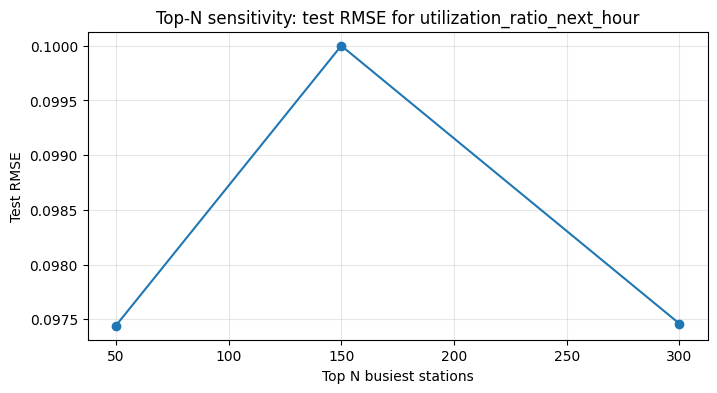

In [11]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    topn_rows = []
    topn_artifacts = {}

    for top_n in TOP_N_GRID:
        model_df = build_model_df(feature_df, PRIMARY_TARGET, ABLATION_SETS['All v7 features'], top_n=top_n)
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(train_df, valid_df, test_df, ABLATION_SETS['All v7 features'], PRIMARY_TARGET)

        test_metrics = metrics_df.loc[metrics_df['split'] == 'test'].sort_values('r2', ascending=False).iloc[0].to_dict()
        test_metrics['top_n_stations'] = top_n
        topn_rows.append(test_metrics)
        topn_artifacts[top_n] = {'metrics_df': metrics_df, 'artifacts': artifacts}

    topn_results = pd.DataFrame(topn_rows).sort_values('top_n_stations')
    display(topn_results)

    plt.figure(figsize=(8, 4))
    plt.plot(topn_results['top_n_stations'], topn_results['rmse'], marker='o')
    plt.title('Top-N sensitivity: test RMSE for utilization_ratio_next_hour')
    plt.xlabel('Top N busiest stations')
    plt.ylabel('Test RMSE')
    plt.grid(True, alpha=0.3)
    plt.show()



## 9) Experiment 2 - feature ablation around availability state

This is the most important follow-on experiment after v7. It answers whether the improvement is really coming from the new capacity-aware station-state features.


,model,split,rmse,mae,r2,experiment,feature_count
0,Random Forest,test,0.100000,0.068509,0.835604,All v7 features,64
2,Random Forest (deeper),test,0.103017,0.070454,0.825534,Availability-state + calendar only,37
3,Random Forest,test,0.148007,0.106752,0.639874,Raw-flow + calendar only,36
1,Random Forest,test,0.148339,0.107139,0.638253,No availability-state features,43


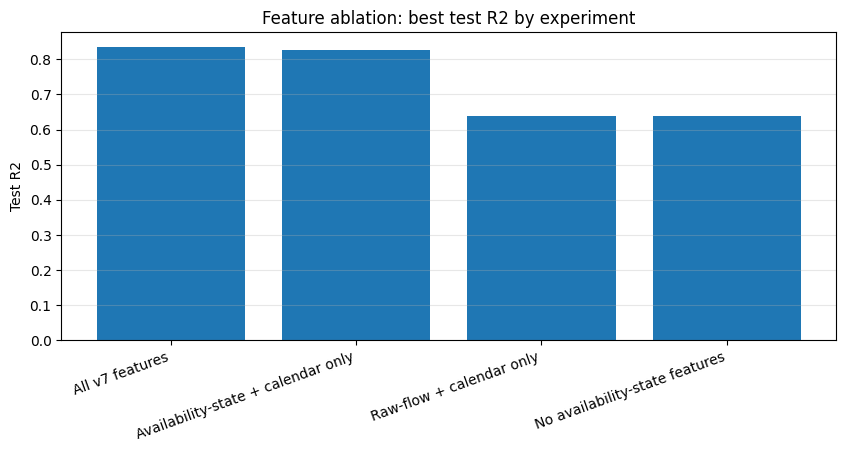

In [10]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    ablation_rows = []
    ablation_artifacts = {}

    for label, cols in ABLATION_SETS.items():
        model_df = build_model_df(feature_df, PRIMARY_TARGET, cols, top_n=DEFAULT_TOP_N_STATIONS)
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(train_df, valid_df, test_df, cols, PRIMARY_TARGET)

        best_test = metrics_df.loc[metrics_df['split'] == 'test'].sort_values('r2', ascending=False).iloc[0].to_dict()
        best_test['experiment'] = label
        best_test['feature_count'] = len(cols)
        ablation_rows.append(best_test)
        ablation_artifacts[label] = {'metrics_df': metrics_df, 'artifacts': artifacts}

    ablation_results = pd.DataFrame(ablation_rows).sort_values('r2', ascending=False)
    display(ablation_results)

    plt.figure(figsize=(10, 4))
    plt.bar(ablation_results['experiment'], ablation_results['r2'])
    plt.title('Feature ablation: best test R2 by experiment')
    plt.ylabel('Test R2')
    plt.xticks(rotation=20, ha='right')
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()



## 10) Experiment 3 - compare all rows vs capacity-known rows only

Even though v7 coverage is very high, this comparison is useful because it tests how sensitive the results are to the live-GBFS capacity merge.


In [11]:

if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    subset_rows = []
    subset_defs = [
        ('All usable rows', False),
        ('Capacity-known rows only', True),
    ]

    subset_features = ABLATION_SETS['All v7 features']

    for label, require_known in subset_defs:
        model_df = build_model_df(
            feature_df,
            PRIMARY_TARGET,
            subset_features,
            top_n=DEFAULT_TOP_N_STATIONS,
            require_capacity_known=require_known,
        )
        train_df, valid_df, test_df = chronological_split(model_df)
        metrics_df, artifacts = fit_regression_suite(train_df, valid_df, test_df, subset_features, PRIMARY_TARGET)
        best_test = metrics_df.loc[metrics_df['split'] == 'test'].sort_values('r2', ascending=False).iloc[0].to_dict()
        best_test['subset'] = label
        best_test['rows_used'] = len(model_df)
        subset_rows.append(best_test)

    subset_results = pd.DataFrame(subset_rows).sort_values('r2', ascending=False)
    display(subset_results)


,model,split,rmse,mae,r2,subset,rows_used
0,Random Forest,test,0.100000,0.068509,0.835604,All usable rows,350000
1,Random Forest,test,0.098619,0.067737,0.835514,Capacity-known rows only,350000



## 11) Experiment 4 - operational alert tasks

A rebalancing system often needs threshold decisions, not only a regression score. These targets are more operationally meaningful:

- `nearly_empty_next_hour`
- `nearly_full_next_hour`


In [12]:

def add_alert_targets(df):
    out = df.copy().sort_values(['station_key', 'hour']).reset_index(drop=True)

    if 'utilization_ratio_next_hour' in out.columns:
        out['nearly_empty_next_hour'] = (out['utilization_ratio_next_hour'] <= 0.10).astype('float')
        out['nearly_full_next_hour'] = (out['utilization_ratio_next_hour'] >= 0.90).astype('float')
    else:
        raise ValueError('utilization_ratio_next_hour not found.')

    out.loc[out['utilization_ratio_next_hour'].isna(), ['nearly_empty_next_hour', 'nearly_full_next_hour']] = np.nan
    return out


def fit_classifier(train_df, valid_df, test_df, feature_cols, target_col):
    prep, X_train, X_valid, X_test, y_train, y_valid, y_test = prepare_xy(train_df, valid_df, test_df, feature_cols, target_col)

    clf = RandomForestClassifier(
        n_estimators=180,
        max_depth=18,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_train, y_train.astype(int))

    valid_prob = clf.predict_proba(X_valid)[:, 1]
    test_prob = clf.predict_proba(X_test)[:, 1]
    valid_pred = (valid_prob >= 0.5).astype(int)
    test_pred = (test_prob >= 0.5).astype(int)

    metrics = pd.DataFrame([
        {
            'split': 'validation',
            'precision': precision_score(y_valid, valid_pred, zero_division=0),
            'recall': recall_score(y_valid, valid_pred, zero_division=0),
            'f1': f1_score(y_valid, valid_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_valid, valid_prob),
        },
        {
            'split': 'test',
            'precision': precision_score(y_test, test_pred, zero_division=0),
            'recall': recall_score(y_test, test_pred, zero_division=0),
            'f1': f1_score(y_test, test_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, test_prob),
        },
    ])
    return clf, metrics


if not RUN_HEAVY_EXPERIMENTS:
    print('Skipped because RUN_HEAVY_EXPERIMENTS is False.')
else:
    alert_df = add_alert_targets(feature_df)
    alert_features = ABLATION_SETS['All v7 features']
    for target_col in ['nearly_empty_next_hour', 'nearly_full_next_hour']:
        model_df = build_model_df(alert_df, target_col, alert_features, top_n=DEFAULT_TOP_N_STATIONS)
        train_df, valid_df, test_df = chronological_split(model_df)
        _, alert_metrics = fit_classifier(train_df, valid_df, test_df, alert_features, target_col)
        display(Markdown(f'### {target_col}'))
        display(alert_metrics)


### nearly_empty_next_hour

,split,precision,recall,f1,roc_auc
0,validation,0.883123,0.790940,0.834493,0.982346
1,test,0.891667,0.779553,0.831850,0.987098


### nearly_full_next_hour

,split,precision,recall,f1,roc_auc
0,validation,0.878008,0.766556,0.818505,0.980620
1,test,0.877904,0.746707,0.807008,0.985411



## 12) Optional: inspect feature importance for the strongest v7 follow-on run

Run this after the ablation experiment if you want a report-friendly plot showing whether `utilization_ratio_lag_1`, `is_nearly_empty`, and `is_nearly_full` still dominate.


### Top features for: All v7 features

,feature,importance
53,utilization_ratio_lag_1,0.500024
59,is_nearly_full,0.177196
58,is_nearly_empty,0.122331
9,hour_cos,0.023885
0,hour_of_day,0.021718
8,hour_sin,0.015831
57,utilization_ratio_roll_24,0.015787
35,net_flow_roll_3,0.010049
36,net_flow_roll_24,0.008196
52,available_docks_roll_24,0.004419


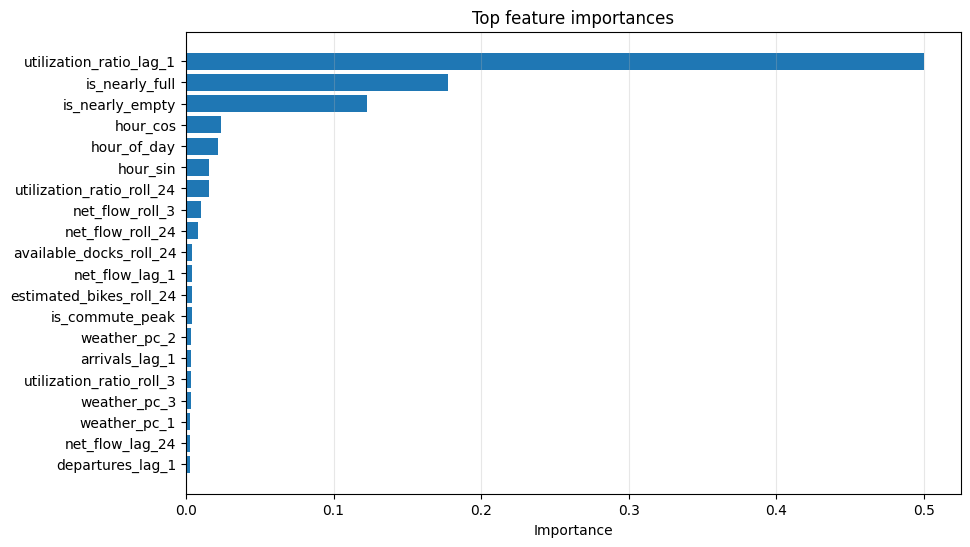

In [13]:

if 'ablation_artifacts' not in globals():
    print('Run the ablation experiment first.')
else:
    best_label = ablation_results.sort_values('r2', ascending=False).iloc[0]['experiment']
    fi = top_feature_importance(ablation_artifacts[best_label]['artifacts'])
    if fi is None:
        print('No feature importance available.')
    else:
        display(Markdown(f'### Top features for: {best_label}'))
        display(fi)
        plot_df = fi.sort_values('importance')
        plt.figure(figsize=(10, 6))
        plt.barh(plot_df['feature'], plot_df['importance'])
        plt.title('Top feature importances')
        plt.xlabel('Importance')
        plt.grid(True, axis='x', alpha=0.3)
        plt.show()



## 13) How to talk about this notebook in the report

### What changed from the old next-steps notebook
- Capacity repair is no longer the main storyline.
- The primary target is now `utilization_ratio_next_hour`, not `departures_next_hour`.
- The most important follow-on question is whether the new availability-state features are truly driving the gain.

### Strong report claims if the follow-on experiments hold
1. **The project now matches the original problem better.**
   You are modeling a bounded availability-style target rather than only raw demand counts.
2. **Station state matters more than weather.**
   If the ablation confirms this, you can say that recent fullness / emptiness is the dominant signal.
3. **The model is operationally useful.**
   If the alert tasks perform well, you can motivate rebalancing alerts rather than only regression.
4. **The target is still a proxy.**
   Capacity came from a live GBFS feed, so the report should still acknowledge that historical capacity may have changed during 2025.

### Recommended priority order after v7
1. Run the **feature ablation** first.
2. Run the **capacity-known subset comparison** second.
3. Run **top-N sensitivity** third.
4. Run the **nearly empty / nearly full alert tasks** fourth.

That ordering gives you the clearest report story for the least extra work.
